### Directional Splitting



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

In [3]:
def velocity(x, y, t, nu):
    decay = np.exp(-2 * nu * t)

    u = np.sin(x) * np.cos(y) * decay
    v = -np.cos(x) * np.sin(y) * decay

    return u + 1j * v

In [4]:
def m4prime_1d(s):

    s = np.abs(np.asarray(s, dtype=float))
    w = np.zeros_like(s)

    m1 = s <= 1.0
    m2 = (s > 1.0) & (s <= 2.0)

    w[m1] = (
        1
        - 2.5 * s[m1]**2
        + 1.5 * s[m1]**3
    )

    w[m2] = (
        0.5
        * (1 - s[m2])
        * (2 - s[m2])**2
    )

    return w

In [5]:
def p2m(particles, mesh, h, L, B):

    Nx, Ny = mesh.shape
    n = 2
    mesh.fill(0.0)

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = np.zeros(2 * n)
        wy = np.zeros(2 * n)

        ix = np.zeros(2 * n, dtype=int)
        iy = np.zeros(2 * n, dtype=int)

        # -------------------------
        # X direction
        # -------------------------

        for k, di in enumerate(range(-n + 1, n + 1)):

            ig = (i0 + di) % Nx

            dx = xp - (i0 + di) * h

            # periodic distance
            dx -= L * np.round(dx / L)

            sx = dx / h

            wx[k] = m4prime_1d(np.array([sx]))[0]
            ix[k] = ig

        # -------------------------
        # Y direction
        # -------------------------

        for k, dj in enumerate(range(-n + 1, n + 1)):

            jg = (j0 + dj) % Ny

            dy = yp - (j0 + dj) * h

            # periodic distance
            dy -= B * np.round(dy / B)

            sy = dy / h

            wy[k] = m4prime_1d(np.array([sy]))[0]
            iy[k] = jg

        # particle vorticity contribution
        ap = p["a"] / h**2


        for k in range(4):
            for l in range(4):
                mesh[ix[k], iy[l]] += ap * wx[k] * wy[l]

        """c = np.outer(wx, wy)

        ix = (i0 + np.arange(-n + 1, n + 1)) % Nx
        iy = (j0 + np.arange(-n + 1, n + 1)) % Ny

        mesh[np.ix_(ix, iy)] += c * ap"""

    return mesh

In [6]:
def poisson_solver(omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY = np.meshgrid(kx,ky,indexing="ij")
    K2 = KX ** 2 + KY ** 2

    K2[0,0]=1.0

    omega_hat=np.fft.fft2(omega)

    psi_hat=-omega_hat/K2
    psi_hat[0,0]=0.0

    psi=np.real(np.fft.ifft2(psi_hat))

    u_hat=1j*KY*psi_hat
    v_hat=-1j*KX*psi_hat

    u=np.real(np.fft.ifft2(u_hat))
    v=np.real(np.fft.ifft2(v_hat))

    U = u + 1j * v

    return U

In [7]:
def m2p(particles, mesh, h, type):

    Nx, Ny = mesh.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        wx = [0.0, 0.0, 0.0, 0.0]
        ix = [0, 0, 0, 0]

        for k, di in enumerate(range(-1, 3)):
            ig = (i0 + di) % Nx
            xg = (i0 + di) * h
            sx = (xp - xg) / h
            wx[k] = m4prime_1d(np.atleast_1d(sx))[0]
            ix[k] = ig

        wy = [0.0, 0.0, 0.0, 0.0]
        iy = [0, 0, 0, 0]

        for k, dj in enumerate(range(-1, 3)):
            jg = (j0 + dj) % Ny
            yg = (j0 + dj) * h
            sy = (yp - yg) / h
            wy[k] = m4prime_1d(np.atleast_1d(sy))[0]
            iy[k] = jg

        value = 0.0

        for k in range(4):
            ig = ix[k]
            wxk = wx[k]
            for l in range(4):
                jg = iy[l]
                value += mesh[ig, jg] * wxk * wy[l]

        if type == 'v':
            p["u"] = value
        elif type == 'w':
            p["a"] = value * h**2
        else:
            raise ValueError("type must be 'v' or 'w'")

    return particles

In [8]:
def advect(particles, dt, Lx, Ly, dirn, dimn):

    if dimn == 1:
        for p in particles:

            if dirn == 0:
                p["pos"] += np.real(p["u"]) * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = np.imag(p["u"]) * 1j

            elif dirn == 1:
                p["pos"] += p["u"] * dt

                x = np.real(p["pos"]) % Lx
                y = np.imag(p["pos"]) % Ly

                u = 0

            p["pos"] = x + 1j*y
            p['u'] = u

    elif dimn == 2:

        for p in particles:
            p['pos'] += p['u'] * dt
            p['u'] = 0
            
    return particles

In [9]:
def p2m2(particles, mesh, h):

    Nx, Ny = mesh.shape
    gamma_grid = np.array(
        [p["a"] for p in particles]
    ).reshape(Nx, Ny)

    omega_grid = gamma_grid / h**2

    return omega_grid

In [10]:
def m2p2(particles, mesh):

    Nx, Ny = mesh.shape

    # Make sure particle count matches mesh
    if len(particles) != Nx * Ny:
        raise ValueError(
            "Number of particles must equal Nx * Ny"
        )

    k = 0

    for i in range(Nx):

        for j in range(Ny):

            particles[k]["a"] = mesh[i, j]

            k += 1

    return particles

In [11]:
def diffusion_solver (omega, h):

    Nx, Ny = omega.shape

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY=np.meshgrid(kx,ky,indexing="ij")
    K2=KX**2+KY**2

    K2[0,0]=1.0


    #diffusion

    omega_hat=np.fft.fft2(omega)

    diffusion = np.exp(-nu * K2 * dt)

    omega_hat *= diffusion

    omega = np.real(np.fft.ifft2(omega_hat))

    return omega

In [12]:
def remeshing(particles, mesh, h, dirn, L, B):

    Nx, Ny = mesh.shape

    if dirn == 0:

        xp, yp, gamma, up = [], [], [], []

        for p in particles:
            xp.append(np.real(p["pos"]))
            yp.append(np.imag(p["pos"]))
            gamma.append(p["a"])
            up.append(p["u"])

        xp = np.array(xp)
        yp = np.array(yp)
        gamma = np.array(gamma)
        up = np.array(up)

        # =========================================================
        # Intermediate X-remeshed circulation
        # =========================================================

        gamma_x = np.zeros((Nx, Ny), dtype=float)
        u_x = np.zeros((Nx, Ny), dtype=complex)

        # =========================================================
        # Base indices
        # =========================================================

        i0 = np.floor(xp / h).astype(int) 

        j0 = np.floor(yp / h).astype(int) % Ny

        # =========================================================
        # Four-point X stencil
        # =========================================================

        for di in range(-1, 3):

            ii = (i0 + di) % Nx

            x_grid = (i0 + di) * h

            dx = xp - x_grid

            dx -= L * np.round(dx / L)

            sx = dx / h

            wx = m4prime_1d(sx)

            # Accumulate Gamma * Wx
            np.add.at(gamma_x, (ii, j0), gamma * wx)
            np.add.at(u_x, (ii, j0), up * wx)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                particles_new.append({
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_x[i, j],
                    "u": u_x[i, j]
                })

        return particles_new


    elif dirn == 1:

        xp = np.array([np.real(p["pos"]) for p in particles])

        yp = np.array([np.imag(p["pos"]) for p in particles])

        # This is already Gamma * Wx
        gamma_x = np.array([p["a"] for p in particles])

        # =========================================================
        # Final circulation
        # =========================================================

        gamma_new = np.zeros((Nx, Ny), dtype=float)

        # =========================================================
        # Base Y index
        # =========================================================

        j0 = np.floor(yp / h).astype(int)

        # =========================================================
        # X index stays fixed
        # =========================================================

        i0 = np.floor(xp / h).astype(int) % Nx

        # =========================================================
        # Four-point Y stencil
        # =========================================================

        for dj in range(-1, 3):

            jj = (j0 + dj) % Ny

            y_grid = (j0 + dj) * h

            dy = yp - y_grid
                        
            dy -= L * np.round(dy / L)

            sy = dy / h

            wy = m4prime_1d(sy)

            # =====================================================
            # IMPORTANT
            #
            # gamma_x = Gamma * Wx
            #
            # Therefore:
            #
            # gamma_x * Wy
            #
            # = Gamma * Wx * Wy
            # =====================================================

            np.add.at(gamma_new, (i0, jj), gamma_x * wy)

        # =========================================================
        # Reconstruct YOUR particle format
        # =========================================================

        x = np.arange(Nx) * h
        y = np.arange(Ny) * h

        X, Y = np.meshgrid(x, y, indexing="ij")

        particles_new = []

        for i in range(Nx):

            for j in range(Ny):

                p = {
                    "pos": X[i, j] + 1j * Y[i, j],
                    "a": gamma_new[i, j]
                }

                particles_new.append(p)

        # IMPORTANT: return the new particle list
        return particles_new  



In [100]:
"""CFL = 0.2


umax = max(abs(np.real(velocity(np.real(p['pos']), np.imag(p['pos']), ))) for p in particles)
vmax = max(abs(np.imag(p["u"])) for p in particles)

dt = CFL * h / max(umax, vmax)
dt"""

'CFL = 0.2\n\n\numax = max(abs(np.real(velocity(np.real(p[\'pos\']), np.imag(p[\'pos\']), ))) for p in particles)\nvmax = max(abs(np.imag(p["u"])) for p in particles)\n\ndt = CFL * h / max(umax, vmax)\ndt'

In [13]:
#Subspace 
L = 2*np.pi
B = 2*np.pi

#Constants
#Re = 10
nu = 0.1    #0.1
T = 0.0125
dt = 0.0125

#Particles
Nxp = 100
Nyp = 100

h = L/Nxp

#Particles in grid
X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                  np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

#Finding vorticity of particles analytically
wm = vorticity(X,Y, 0, nu)

vmax = np.max(np.abs(vorticity(X,Y, 0, nu)))
vmin = -vmax

#Storing information in particle
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), wm.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

# Mesh
Nxm = Nxp
Nym = Nyp

mesh = np.zeros((Nxm, Nym))

flag = 1

in_flag = False

out_flag = False

In [ ]:
for i in np.arange(0, T, dt):
    print(i + dt)

    wm = p2m(particles, mesh, h, L, B)

    um = poisson_solver(wm, h)

    particles = m2p(particles, um, h,'v')

    # your existing advection
    for dimn in [0, 1]:
        particles = advect(particles, dt, L, B, dimn, 1)
        particles = remeshing(particles, mesh, h, dimn, L, B)

    # P2M of the advected particles
    wm = p2m(particles, mesh, h, L, B)

    wm = diffusion_solver(wm, h)

    particles = m2p(particles, wm, h, 'w')

In [ ]:
def VIC(L, B, T, dt, nu, N):

    W = []

    #Particles
    Nxp = N
    Nyp = N

    h = L/Nxp

    #Particles in grid
    X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                    np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

    #Finding vorticity of particles analytically
    wm = vorticity(X,Y, 0, nu)

    vmax = np.max(np.abs(vorticity(X,Y, 0, nu)))
    vmin = -vmax

    #Storing information in particle
    particles = []
    for x, y, w in zip(X.ravel(), Y.ravel(), wm.ravel()):
        p = {}
        p['pos'] = x + y * 1j
        #p['y'] = y
        p['a'] = w * (h ** 2)
        particles.append(p)

    # Mesh
    Nxm = Nxp
    Nym = Nyp

    mesh = np.zeros((Nxm, Nym))


    for i in np.arange(0, T, dt):

        wm = p2m(particles, mesh, h, L, B)

        um = poisson_solver(wm, h)

        particles = m2p(particles, um, h, 'v')

        # your existing advection
        for dimn in [0, 1]:
            particles = advect(particles, dt, L, B, dimn, 1)
            particles = remeshing(particles, mesh, h, dimn, L, B)

        # P2M of the advected particles
        wm = p2m(particles, mesh, h, L, B)

        wm = diffusion_solver(wm, h)

        particles = m2p(particles, wm, h, 'w')

    W.append(wm)

    return W

In [18]:
WM = VIC(L, B, 1, dt, nu, 100)

In [ ]:
p = particles[0]

xp = np.real(p["pos"])
yp = np.imag(p["pos"])

i0 = int(np.floor(xp / h))
j0 = int(np.floor(yp / h))

print("particle position:", xp, yp)
print("i0, j0:", i0, j0)

wx = []
wy = []

for di in range(-1, 3):
    sx = (xp - (i0 + di)*h) / h
    wx.append(m4prime_1d(np.atleast_1d(sx))[0])

for dj in range(-1, 3):
    sy = (yp - (j0 + dj)*h) / h
    wy.append(m4prime_1d(np.atleast_1d(sy))[0])

print("wx =", wx)
print("wy =", wy)
print("sum wx =", sum(wx))
print("sum wy =", sum(wy))

particle position: 2.525253378283573e-21 8.592236793511084e-23
i0, j0: 0 0
wx = [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(-0.0)]
wy = [np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(-0.0)]
sum wx = 1.0
sum wy = 1.0


In [31]:
wm_test = p2m(particles, mesh, h, L, B)

W_exact = 2 * np.sin(X) * np.sin(Y)

error = wm_test - W_exact

print("Max error      :", np.max(np.abs(error)))
print("L2 error       :", np.sqrt(np.mean(error**2)))
print(
    "Relative error :",
    np.linalg.norm(error) / np.linalg.norm(W_exact)
)

Max error      : 2.3092638912203256e-14
L2 error       : 2.813254218919015e-15
Relative error : 2.8132542189190154e-15


In [32]:
a = np.array([np.real(p["a"]) for p in particles])

print("min a :", np.min(a))
print("max a :", np.max(a))
print("mean a:", np.mean(a))
print("sum a :", np.sum(a))
print("L2 a  :", np.linalg.norm(a))


min a : -0.007895683520871487
max a : 0.007895683520871487
mean a: -1.1102230246251566e-20
sum a : -1.1102230246251565e-16
L2 a  : 0.3947841760435744


In [33]:
x = np.array([np.real(p["pos"]) for p in particles])
y = np.array([np.imag(p["pos"]) for p in particles])

a_exact = 2*np.sin(x)*np.sin(y)*h**2

print("max |a - a_exact|:",
      np.max(np.abs(a - a_exact)))

print("relative error:",
      np.linalg.norm(a - a_exact) / np.linalg.norm(a_exact))


a = np.array([np.real(p["a"]) for p in particles])

positive = np.sum(a[a > 0])
negative = np.sum(a[a < 0])

print("positive circulation sum:", positive)
print("negative circulation sum:", negative)
print("total:", positive + negative)

max |a - a_exact|: 0.0
relative error: 0.0
positive circulation sum: 15.989473461165272
negative circulation sum: -15.989473461165272
total: 0.0


In [42]:
wm = p2m(particles, mesh, h, L, B)

print("P2M at positive vortex  :", wm[25, 25])
print("P2M at negative vortex  :", wm[75, 25])

print("Exact positive          :", vorticity(X[25,25], Y[25,25], 0, nu))
print("Exact negative          :", vorticity(X[75,25], Y[75,25], 0, nu))

P2M at positive vortex  : 2.0000000000000018
P2M at negative vortex  : -1.9999999999999982
Exact positive          : 2.0
Exact negative          : -2.0


In [41]:
total = 0.0

for p in particles:

    xp = np.real(p["pos"])
    yp = np.imag(p["pos"])

    i0 = int(np.floor(xp / h))
    j0 = int(np.floor(yp / h))

    for di in range(-1, 3):
        ig = (i0 + di) % Nxm

        dx = xp - (i0 + di) * h
        dx -= L * np.round(dx / L)
        sx = dx / h

        wx = m4prime_1d(np.array([sx]))[0]

        if ig != 25:
            continue

        for dj in range(-1, 3):
            jg = (j0 + dj) % Nym

            dy = yp - (j0 + dj) * h
            dy -= B * np.round(dy / B)
            sy = dy / h

            wy = m4prime_1d(np.array([sy]))[0]

            if jg != 25:
                continue

            contribution = (p["a"] / h**2) * wx * wy
            total += contribution

print("Manual total at (25,25):", total)
print("Actual P2M at (25,25):", wm[25,25])

Manual total at (25,25): 2.0000000000000018
Actual P2M at (25,25): 0.0


In [93]:
um = poisson_solver(wm, h)
u_exact = velocity(X, Y, i, nu)

velocity_error = um - u_exact

print("Velocity max error:",
      np.max(np.abs(velocity_error)))

print("Velocity L2 error:",
      np.sqrt(np.mean(np.abs(velocity_error)**2)))

print("Velocity relative error:",
      np.linalg.norm(velocity_error) / np.linalg.norm(u_exact))


Velocity max error: 0.18026974675539376
Velocity L2 error: 0.1274699603735202
Velocity relative error: 0.22018196589987246


In [15]:
W_exact = vorticity(X,Y,T, nu)
error = wm - W_exact

print("Max error      :", np.max(np.abs(error)))
print("L2 error       :", np.sqrt(np.mean(error**2)))
print("Relative error :", 
      np.linalg.norm(error) / np.linalg.norm(W_exact))

Max error      : 2.886579864025407e-15
L2 error       : 5.928559183056697e-16
Relative error : 5.988142193414796e-16


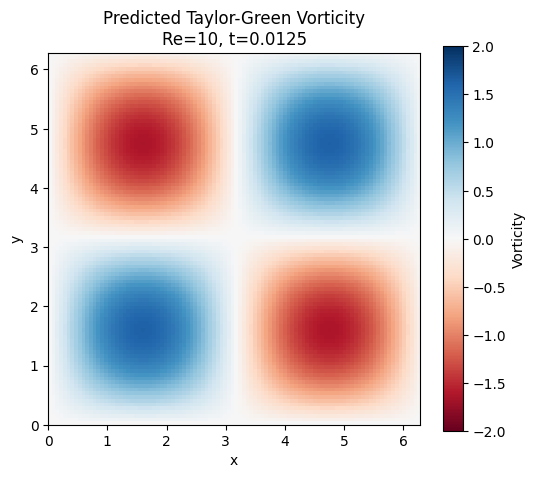

In [20]:
plt.figure(figsize=(6,5))

plt.imshow(
    WM[-1],
    extent=[0, L, 0, B],
    origin="lower",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Predicted Taylor-Green Vorticity\nRe={1/nu:.0f}, t={T}")

plt.show()

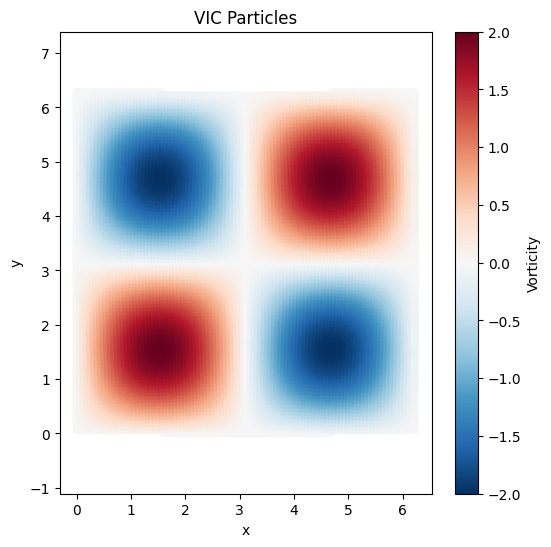

In [27]:
def plot_vic_particles(particles, h, title="VIC Particles"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    # Convert circulation back to vorticity
    w = np.array([p["a"] for p in particles]) / h**2

    #vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

plot_vic_particles(particles, h)

In [22]:
import pickle
import os

if os.path.exists("data.pkl"):
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)
else:
    data = {}

data["predicted"] = WM[-1]

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

data["pred_list"] = WM

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


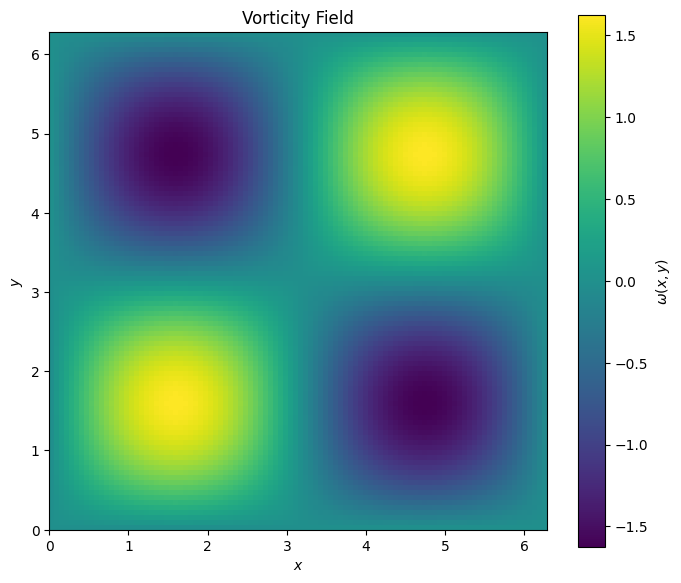

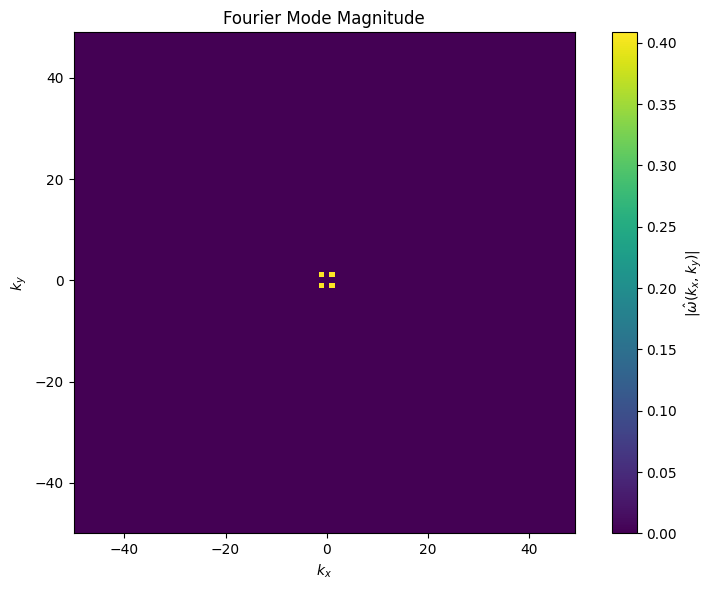

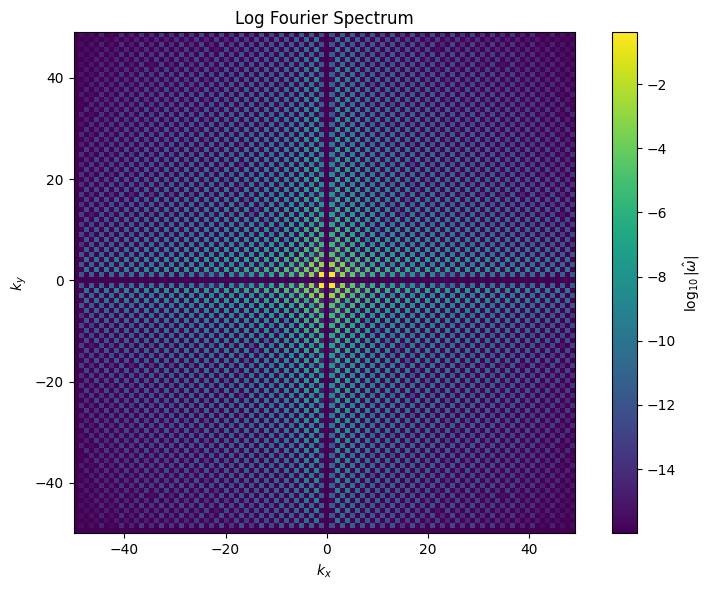

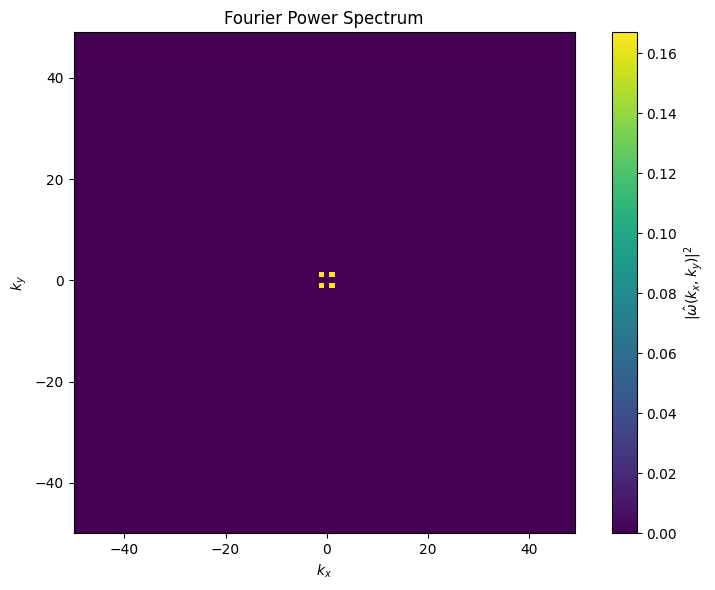

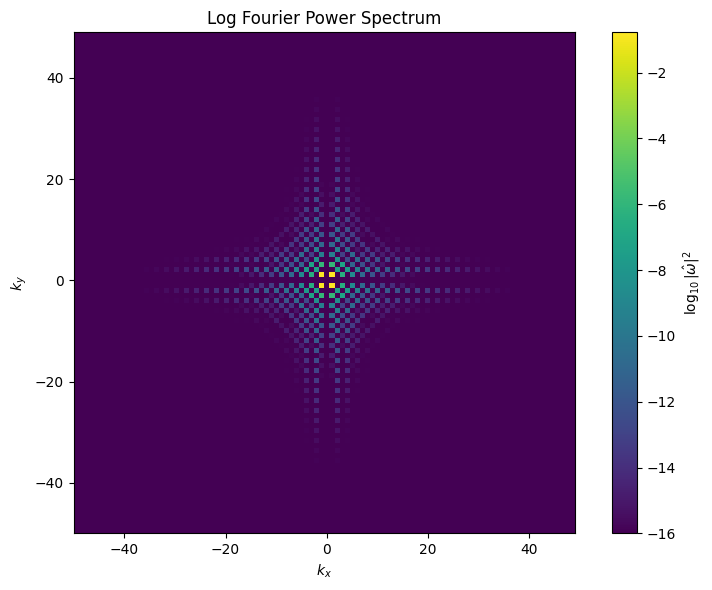

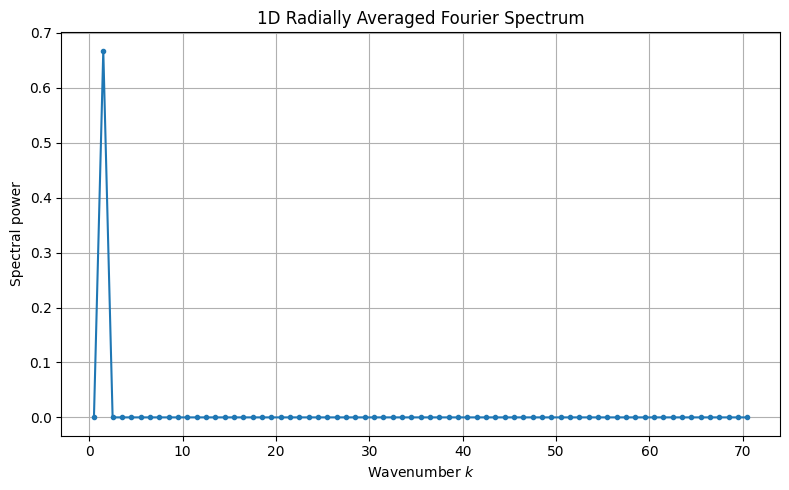

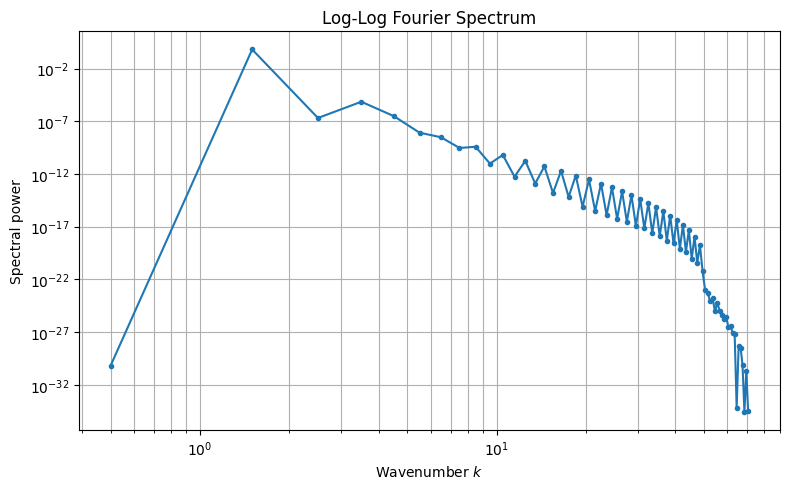



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       1.00      -1.00     4.085740e-01      
2       -1.00     1.00      4.085740e-01      
3       1.00      1.00      4.085740e-01      
4       -1.00     -1.00     4.085740e-01      
5       3.00      1.00      1.199543e-03      
6       -3.00     -1.00     1.199543e-03      
7       3.00      -1.00     1.199543e-03      
8       -3.00     1.00      1.199543e-03      
9       -1.00     3.00      6.112472e-04      
10      1.00      -3.00     6.112472e-04      
11      1.00      3.00      6.112472e-04      
12      -1.00     -3.00     6.112472e-04      
13      -3.00     -3.00     2.441157e-04      
14      3.00      3.00      2.441157e-04      
15      3.00      -3.00     2.441157e-04      


Strongest Fourier Mode
kx                 = 1.0000
ky                 = -1.0000
|omega_hat|        = 4.085740e-01


Spectral Statistics
Total spectral power = 6

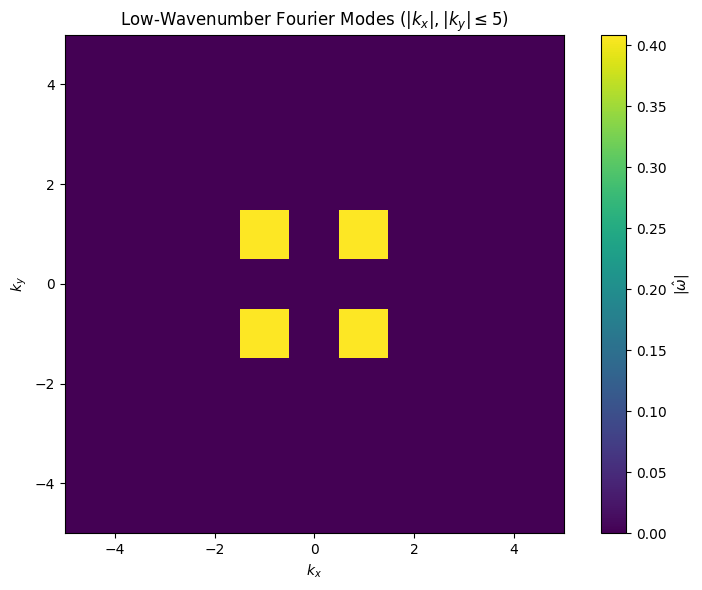



Analysis Complete


In [21]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = WM[-1]


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")

In [80]:
# ==========================================
# CONTROLLED P2M KERNEL TEST
# ==========================================

shift_x = 0.25 * h
shift_y = 0.25 * h

# Create particles on the original grid
test_particles = []

for i in range(Nx):
    for j in range(Ny):

        x = i * h
        y = j * h

        w = np.sin(x) * np.sin(y)

        test_particles.append({
            "pos": (x + shift_x) % L + 1j * ((y + shift_y) % B),
            "a": w * h**2
        })


# ------------------------------------------
# P2M
# ------------------------------------------

test_mesh = np.zeros((Nx, Ny))

wm_test = p2m(
    test_particles,
    test_mesh,
    h,
    L,
    B
)


# ------------------------------------------
# Exact field on mesh
# ------------------------------------------

W_exact_test = np.sin(X - shift_x) * np.sin(Y - shift_y)

error = wm_test - W_exact_test


print("======================================")
print("CONTROLLED P2M TEST")
print("======================================")

print("Max error      :", np.max(np.abs(error)))

print("L2 error       :", np.sqrt(np.mean(error**2)))

print("Relative error :",
      np.linalg.norm(error) / np.linalg.norm(W_exact_test))


error = wm - W_exact

error_hat = np.fft.fft2(error)

power = np.abs(error_hat)**2
power /= np.sum(power)

# Shift zero frequency to center
power_shift = np.fft.fftshift(power)

print("Total error power:", np.sum(power))

print("Maximum error-mode power:",
      np.max(power_shift))

# Location of strongest error mode
idx = np.unravel_index(np.argmax(power_shift), power_shift.shape)

print("Strongest error mode index:", idx)

CONTROLLED P2M TEST
Max error      : 4.0862609133052175e-06
L2 error       : 2.748952840613814e-06
Relative error : 5.4979056812276275e-06
Total error power: 1.0
Maximum error-mode power: 0.25
Strongest error mode index: (np.int64(49), np.int64(49))


In [92]:
# ============================================================
# TGV DISPLACEMENT + EXACT NEW CIRCULATION + P2M
# ============================================================

# Make sure particles are at their original t = 0 positions
# before running this test.

# ------------------------------------------------------------
# 1. Store original positions
# ------------------------------------------------------------

x0 = np.array([np.real(p["pos"]) for p in particles])
y0 = np.array([np.imag(p["pos"]) for p in particles])


# ------------------------------------------------------------
# 2. Give particles EXACT TGV velocity at t = 0
# ------------------------------------------------------------

for p in particles:

    x = np.real(p["pos"])
    y = np.imag(p["pos"])

    p["u"] = velocity(x, y, 0.0, nu)


# ------------------------------------------------------------
# 3. YOUR EXISTING ADVECTION
# ------------------------------------------------------------

ux = np.array([np.real(p["u"]) for p in particles])
uy = np.array([np.imag(p["u"]) for p in particles])

particles = advect(particles, dt, L, B, 1, 2)

dx = ux * dt
dy = uy * dt

print("Maximum |dx|/h:", np.max(np.abs(dx / h)))
print("Maximum |dy|/h:", np.max(np.abs(dy / h)))


# ------------------------------------------------------------
# 4. Get the NEW particle positions
# ------------------------------------------------------------

xp = np.array([np.real(p["pos"]) for p in particles])
yp = np.array([np.imag(p["pos"]) for p in particles])


# ------------------------------------------------------------
# 5. IMPORTANT:
#    Give every particle the EXACT circulation corresponding
#    to the NEW position at t = dt
# ------------------------------------------------------------

w_exact_particle = vorticity(xp, yp, dt, nu)

for p, w in zip(particles, w_exact_particle):
    p["a"] = w * h**2


# ------------------------------------------------------------
# 6. P2M
# ------------------------------------------------------------

wm = p2m(particles, mesh, h, L, B)


# ------------------------------------------------------------
# 7. Exact vorticity on the mesh
# ------------------------------------------------------------

W_exact = vorticity(X, Y, dt, nu)


# ------------------------------------------------------------
# 8. Physical-space error
# ------------------------------------------------------------

error = wm - W_exact

print("==============================================")
print("TGV DISPLACEMENT + EXACT PARTICLE CIRCULATION")
print("==============================================")

print("Max error      :", np.max(np.abs(error)))

print("L2 error       :", np.sqrt(np.mean(error**2)))

print("Relative error :",
      np.linalg.norm(error) / np.linalg.norm(W_exact))

Maximum |dx|/h: 0.19894367886486916
Maximum |dy|/h: 0.19894367886486916
TGV DISPLACEMENT + EXACT PARTICLE CIRCULATION
Max error      : 0.0003089965738756195
L2 error       : 9.656931625187765e-05
Relative error : 9.681104157326046e-05


Real vs. control contamination check
--- YOUR FIELD (wm) ---
  power in the 4 physical modes : 99.999999% of total
  power OUTSIDE physical modes  : 6.392e-09  (fraction of total)
  max |omega_hat| outside       : 3.396e-05
--- CONTROL (exact IC, zero solver error) ---
  power in the 4 physical modes : 100.000000% of total
  power OUTSIDE physical modes  : 0.000e+00  (fraction of total)
  max |omega_hat| outside       : 6.829e-17

Your field's off-mode energy is ~497346965165.9x the pure-roundoff control floor.
-> Well above the floor: this is REAL spectral contamination,
   worth investigating in the solver (not just the plot).



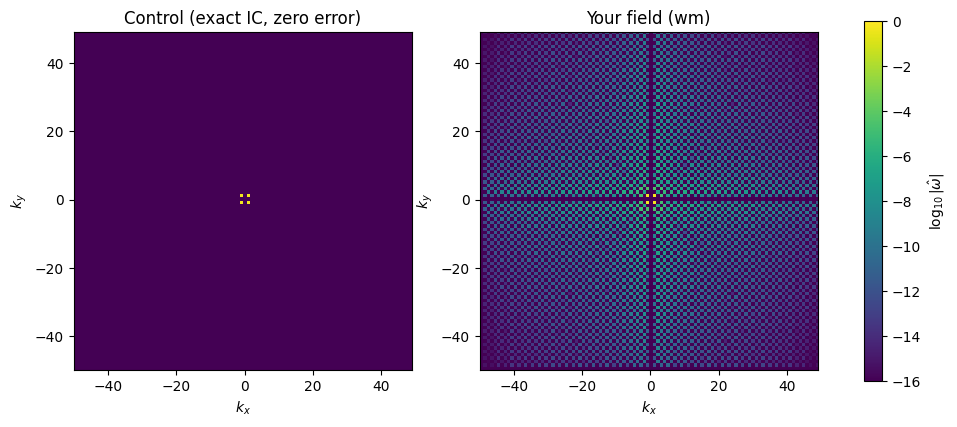

If the LEFT (control) panel still shows checkering, that confirms
it's a rendering artifact -- it CANNOT be a solver bug, since no
solver touched this field. Compare the two panels directly.


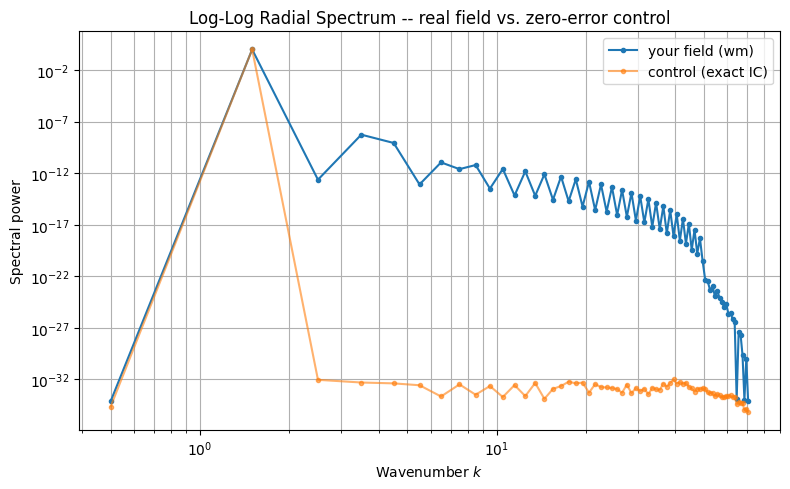

Anywhere the two curves overlap, your field is at the same level as
the zero-error control -- i.e. at the noise floor, not real content.
Only where 'your field' sits CLEARLY above the control curve is
there genuine spectral energy beyond the expected physical mode.

Dominant Fourier modes (flagged against the noise floor)
Rank  kx      ky      |omega_hat|     status      
------------------------------------------------------------
1     -1.00   1.00    4.987369e-01    REAL        
2     1.00    1.00    4.987369e-01    REAL        
3     1.00    -1.00   4.987369e-01    REAL        
4     -1.00   -1.00   4.987369e-01    REAL        
5     -3.00   1.00    3.396258e-05    REAL        
6     3.00    1.00    3.396258e-05    REAL        
7     3.00    -1.00   3.396258e-05    REAL        
8     -3.00   -1.00   3.396258e-05    REAL        
9     1.00    3.00    1.468625e-05    REAL        
10    -1.00   3.00    1.468625e-05    REAL        
11    -1.00   -3.00   1.468625e-05    REAL        
12 

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FOURIER ANALYSIS OF A 2D VORTICITY FIELD -- WITH A BUILT-IN
# "IS THIS REAL OR IS IT PLOTTING" CONTROL COMPARISON
# ============================================================
#
# The core idea: rather than staring at a checkered plot and
# guessing, run the IDENTICAL pipeline on a case with a KNOWN,
# essentially-zero-error answer -- the pure analytic Taylor-Green
# IC sampled on your grid, never touched by your solver. Its true
# spectrum has exactly 4 nonzero modes, at (kx,ky) = (+-1,+-1);
# everything else should be at the double-precision floor
# (~1e-16 relative), not a real feature.
#
# If your actual field's "power outside the physical modes" is
# close to that floor, any checkering you see when plotting it is
# a visualization artifact (imshow resampling a small array +
# log-colour-mapping near-zero, effectively-random roundoff noise).
# If it's orders of magnitude above the floor, that's real
# spectral contamination worth chasing (e.g. the directional-
# splitting / remeshing-kernel leakage we've traced before).

# ------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------

omega = wm          # <-- your actual vorticity matrix
L = 2 * np.pi
B = 2 * np.pi
Nx, Ny = omega.shape
dx, dy = L / Nx, B / Ny


# ------------------------------------------------------------
# 2. SPECTRUM HELPER
# ------------------------------------------------------------

def compute_spectrum(field, Nx, Ny, dx, dy):
    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
    field_hat = np.fft.fft2(field) / (Nx * Ny)   # normalized
    return field_hat, kx, ky


def physical_mode_mask(kx, ky):
    """Where the exact Taylor-Green solution's energy actually
    lives: the four corner modes at (+-1,+-1)."""
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    return (np.abs(np.abs(KX) - 1) < 0.5) & (np.abs(np.abs(KY) - 1) < 0.5)


def report_contamination(field_hat, kx, ky, label):
    mag = np.abs(field_hat)
    mask = physical_mode_mask(kx, ky)
    power_total = np.sum(mag**2)
    power_phys = np.sum(mag[mask]**2)
    power_out = power_total - power_phys
    max_out = np.max(mag[~mask]) if np.any(~mask) else 0.0
    frac_out = power_out / power_total if power_total > 0 else 0.0
    print(f"--- {label} ---")
    print(f"  power in the 4 physical modes : {100*power_phys/power_total:.6f}% of total")
    print(f"  power OUTSIDE physical modes  : {frac_out:.3e}  (fraction of total)")
    print(f"  max |omega_hat| outside       : {max_out:.3e}")
    return frac_out, max_out


# ------------------------------------------------------------
# 3. BUILD THE ZERO-ERROR CONTROL (same grid, exact analytic IC,
#    never touched by your solver) -- this is the reference for
#    "what does a genuinely clean field's spectrum look like on
#    this exact plotting pipeline"
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy
Xc, Yc = np.meshgrid(x, y, indexing="ij")
omega_control = 2 * np.sin(Xc) * np.sin(Yc)

omega_hat, kx, ky = compute_spectrum(omega, Nx, Ny, dx, dy)
control_hat, _, _ = compute_spectrum(omega_control, Nx, Ny, dx, dy)

print("=" * 60)
print("Real vs. control contamination check")
print("=" * 60)
frac_real, max_real = report_contamination(omega_hat, kx, ky, "YOUR FIELD (wm)")
frac_ctrl, max_ctrl = report_contamination(control_hat, kx, ky, "CONTROL (exact IC, zero solver error)")
print()
ratio = max_real / max(max_ctrl, 1e-300)
print(f"Your field's off-mode energy is ~{ratio:.1f}x the pure-roundoff control floor.")
if ratio < 1e3:
    print("-> Close to the floor: what you're seeing is almost certainly a")
    print("   PLOTTING/roundoff artifact, not a real numerical problem.")
else:
    print("-> Well above the floor: this is REAL spectral contamination,")
    print("   worth investigating in the solver (not just the plot).")
print()


# ------------------------------------------------------------
# 4. SIDE-BY-SIDE SPECTRUM PLOT, ARTIFACT-FREE RENDERING
#
#    interpolation='nearest' is the key fix: matplotlib's default
#    interpolation resamples/antialiases when the array doesn't
#    map 1:1 to display pixels, and THAT resampling is what
#    produces moire/checkerboard texture -- independent of
#    whatever the underlying data actually looks like.
# ------------------------------------------------------------

kx_s = np.fft.fftshift(kx)
ky_s = np.fft.fftshift(ky)
extent = [kx_s.min(), kx_s.max(), ky_s.min(), ky_s.max()]

log_real = np.log10(np.abs(np.fft.fftshift(omega_hat)) + 1e-300)
log_ctrl = np.log10(np.abs(np.fft.fftshift(control_hat)) + 1e-300)
vmin, vmax = -16, 0   # fixed, shared scale -- so the two panels are
                       # actually comparable, not each auto-stretched

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title in zip(
    axes, [log_ctrl, log_real],
    ["Control (exact IC, zero error)", "Your field (wm)"]
):
    im = ax.imshow(
        data, extent=extent, origin="lower", aspect="equal",
        interpolation="nearest", vmin=vmin, vmax=vmax
    )
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
fig.colorbar(im, ax=axes, label=r"$\log_{10}|\hat{\omega}|$", shrink=0.85)
plt.show()

print("If the LEFT (control) panel still shows checkering, that confirms")
print("it's a rendering artifact -- it CANNOT be a solver bug, since no")
print("solver touched this field. Compare the two panels directly.")


# ------------------------------------------------------------
# 5. RADIAL SPECTRUM WITH AN EXPLICIT NOISE-FLOOR LINE
# ------------------------------------------------------------

KX, KY = np.meshgrid(kx_s, ky_s, indexing="ij")
K = np.sqrt(KX**2 + KY**2)
power = np.abs(np.fft.fftshift(omega_hat))**2
control_power = np.abs(np.fft.fftshift(control_hat))**2

k_max = int(np.ceil(K.max()))
k_bins = np.arange(0, k_max + 1)
k_vals = 0.5 * (k_bins[:-1] + k_bins[1:])
k_spec = np.zeros(len(k_bins) - 1)
k_spec_ctrl = np.zeros(len(k_bins) - 1)
for i in range(len(k_bins) - 1):
    mask = (K >= k_bins[i]) & (K < k_bins[i + 1])
    k_spec[i] = np.sum(power[mask])
    k_spec_ctrl[i] = np.sum(control_power[mask])

plt.figure(figsize=(8, 5))
m1 = k_spec > 0
m2 = k_spec_ctrl > 0
plt.loglog(k_vals[m1], k_spec[m1], "o-", ms=3, label="your field (wm)")
plt.loglog(k_vals[m2], k_spec_ctrl[m2], "o-", ms=3, alpha=0.6, label="control (exact IC)")
plt.xlabel(r"Wavenumber $k$")
plt.ylabel("Spectral power")
plt.title("Log-Log Radial Spectrum -- real field vs. zero-error control")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

print("Anywhere the two curves overlap, your field is at the same level as")
print("the zero-error control -- i.e. at the noise floor, not real content.")
print("Only where 'your field' sits CLEARLY above the control curve is")
print("there genuine spectral energy beyond the expected physical mode.")


# ------------------------------------------------------------
# 6. DOMINANT MODES, WITH NOISE-FLOOR FLAGGING
# ------------------------------------------------------------

mag = np.abs(omega_hat)
noise_floor = max_ctrl * 10   # small safety margin above the control's own floor
flat_idx = np.argsort(mag.ravel())[::-1]

print()
print("=" * 60)
print("Dominant Fourier modes (flagged against the noise floor)")
print("=" * 60)
print(f"{'Rank':<6}{'kx':<8}{'ky':<8}{'|omega_hat|':<16}{'status':<12}")
print("-" * 60)
for rank, idx in enumerate(flat_idx[:15], start=1):
    i, j = np.unravel_index(idx, mag.shape)
    val = mag[i, j]
    status = "REAL" if val > noise_floor else "noise floor"
    print(f"{rank:<6}{kx[i]:<8.2f}{ky[j]:<8.2f}{val:<16.6e}{status:<12}")